# Unsupervised Clustering of Wound Border Features
This notebook performs dimensionality reduction and clustering on the extracted wound border features to identify patterns and group similar wounds.

## Loading Feature Vectors and Cleaning Dataset

In [1]:
## loading extracted feature vectors

import pandas as pd
import numpy as np
# load the full feature vectors csv
try:
    df = pd.read_csv("../outputs/comprehensive_features.csv")
    print(f"Loaded {len(df)} feature rows")
    
    #clean the dataset dropping rows with NaN values
    df_clean = df.dropna()
    image_ids = df_clean["image_id"].values
    features = df_clean.drop(columns=["image_id"]).values
    print(f"{len(features)} rows remainign after dropping NaNs")

except FileNotFoundError:
    print("ERROR: CSV file not found. Please ensure the path is correct or run 'run_pipelines.py' to generate the file.")

Loaded 1219 feature rows
1143 rows remainign after dropping NaNs


## Dimensionality Reduction for Visalization and Clustering with HDBSCAN

### Dimension reduction using PaCMAP

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Plot saved to ../report/fig/pacmap_embedding.png


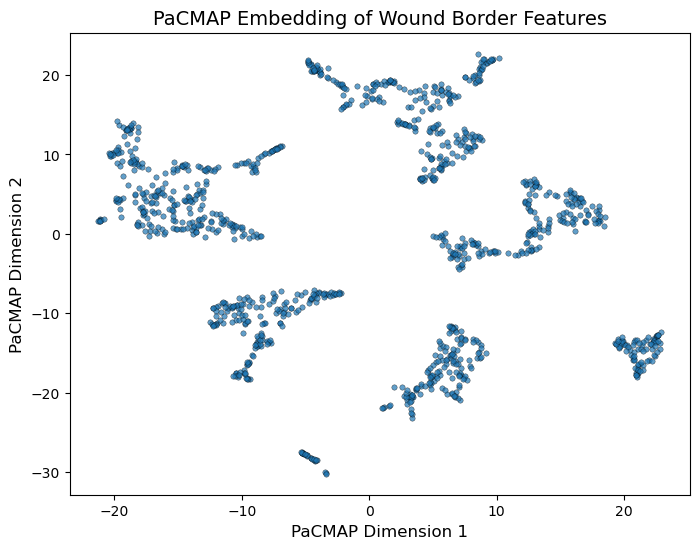

In [2]:
# Diamensionality reduction with PaCMAP
import pacmap
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns 

# ----Scale the Features ---
# Standardizes each feature to have a mean of 0 and a standard deviation of 1, 
# ensuring all features contribute equally.
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# ----Apply PaCMAP for Dimensionality Reduction---
# config for 2D results n_components=2
pmap = pacmap.PaCMAP(
    n_components=2,
    n_neighbors=None,     
    MN_ratio=2,
    FP_ratio=8,
    random_state=42,
    distance='euclidean'
)
embedding = pmap.fit_transform(features_scaled)
plt.style.use('default') # Use a standard plot style
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    s=15,  # Marker size
    alpha=0.7,
    edgecolor='black',
    ax=ax
)

ax.set_title('PaCMAP Embedding of Wound Border Features', fontsize=14)
ax.set_xlabel('PaCMAP Dimension 1', fontsize=12)
ax.set_ylabel('PaCMAP Dimension 2', fontsize=12)
ax.grid(False)

# Save the figure to a file for your report
output_path = "../report/fig/pacmap_embedding.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Plot saved to {output_path}")

plt.show()

### HDBSCAN clustering

In [ ]:
# Clustering using HDBSCAN
import hdbscan
#import numpy as np
# Cluster in reduced 2D space
clusterer = hdbscan.HDBSCAN(
    min_cluster_size= 25,
    min_samples=6,
    cluster_selection_epsilon=0.75,
    cluster_selection_method='eom',
    core_dist_n_jobs=-1,
    metric='euclidean'
)
# Assigning cluster labels for data points spread in 2D map
cluster_labels = clusterer.fit_predict(embedding)

# Add to dataFrame
df_clean["cluster_label"] = cluster_labels

num_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
num_noise = np.sum(cluster_labels == -1)

print(f"Clustering complete. Found {num_clusters} clusters and {num_noise} noise points.")

Clustering complete. Found 7 clusters and 24 noise points.


/opt/anaconda3/envs/wound-pr/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/wound-pr/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/v4/vp4_jyrx03x_4_00k4fv8vyh0000gn/T/ipykernel_1274/4292186956.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["cluster_label"] = cluster_labels


### Visualising HDBSCAN Cluster results

Plot with legend saved to ../report/fig/pacmap_clusters.png


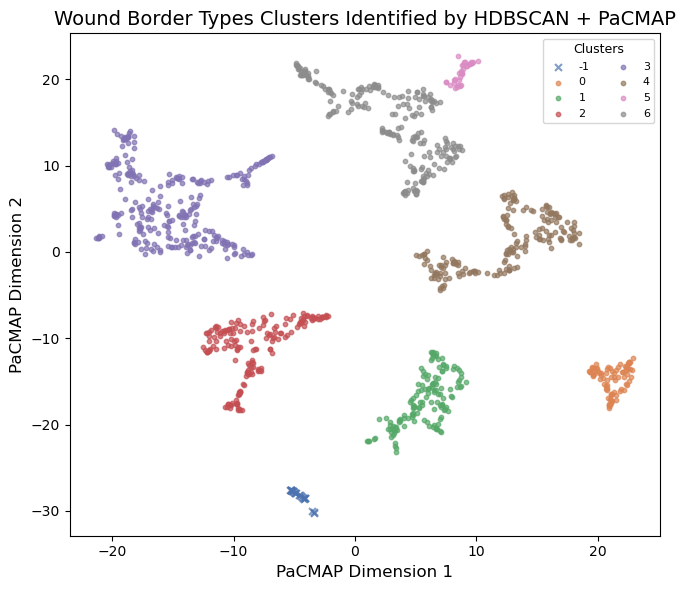

In [ ]:
# visualize the clusters
import matplotlib.pyplot as plt

unique_labels, counts = np.unique(cluster_labels, return_counts=True)

plt.figure(figsize=(8, 6))
palette = sns.color_palette("deep", len(unique_labels))

# Loop through each unique cluster and plot its points separately
for i, label in enumerate(unique_labels):
    # Select the points belonging to the current cluster
    cluster_points = embedding[cluster_labels == label]
    
    # Get the descriptive name from the map
    #descriptive_label = label_map.get(label, f"Cluster {label}")
    
    # Use a different marker for noise points if they exist
    marker = 'x' if label == -1 else 'o'
    size = 25 if label == -1 else 10
    
    plt.scatter(
        cluster_points[:, 0], 
        cluster_points[:, 1],
        c=[palette[i]],  # Assign color from the palette
        s=size,
        marker=marker,
        alpha=0.7,
        label=label # This label will be used in the legend
    )

plt.title("Wound Border Types Clusters Identified by HDBSCAN + PaCMAP", fontsize=14)
plt.xlabel("PaCMAP Dimension 1", fontsize=12)
plt.ylabel("PaCMAP Dimension 2", fontsize=12)
plt.grid(False)

# Create the legend 
plt.legend(
    title='Clusters', 
    loc='upper right',  
    ncol=2,            
    fontsize=8,
    title_fontsize=9
)
# Adjust layout to make sure the legend fits
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust the plot area to make room for the legend

# Save the figure for your report
output_path = "../report/fig/pacmap_clusters.png"
plt.savefig(output_path, dpi=300)
print(f"Plot with legend saved to {output_path}")

plt.show()

## Saving Image Cluster Map

In [ ]:
# Displaing Cluster Details: Number of samples in each cluster
import numpy as np
unique, counts = np.unique(cluster_labels, return_counts=True)
print(dict(zip(unique, counts)))

# Extract image IDs and their cluster assignments
image_clusters = df_clean[["image_id", "cluster_label"]]

# Save to a separate CSV
image_clusters.to_csv("../outputs/image_cluster_map.csv", index=False)

print("Saved cluster assignments to image_cluster_map.csv")

{np.int64(-1): np.int64(24), np.int64(0): np.int64(82), np.int64(1): np.int64(143), np.int64(2): np.int64(171), np.int64(3): np.int64(289), np.int64(4): np.int64(181), np.int64(5): np.int64(33), np.int64(6): np.int64(220)}


## Preview Sample Images by Cluster

Composite sample image saved to ../report/fig/all_cluster_samples.png


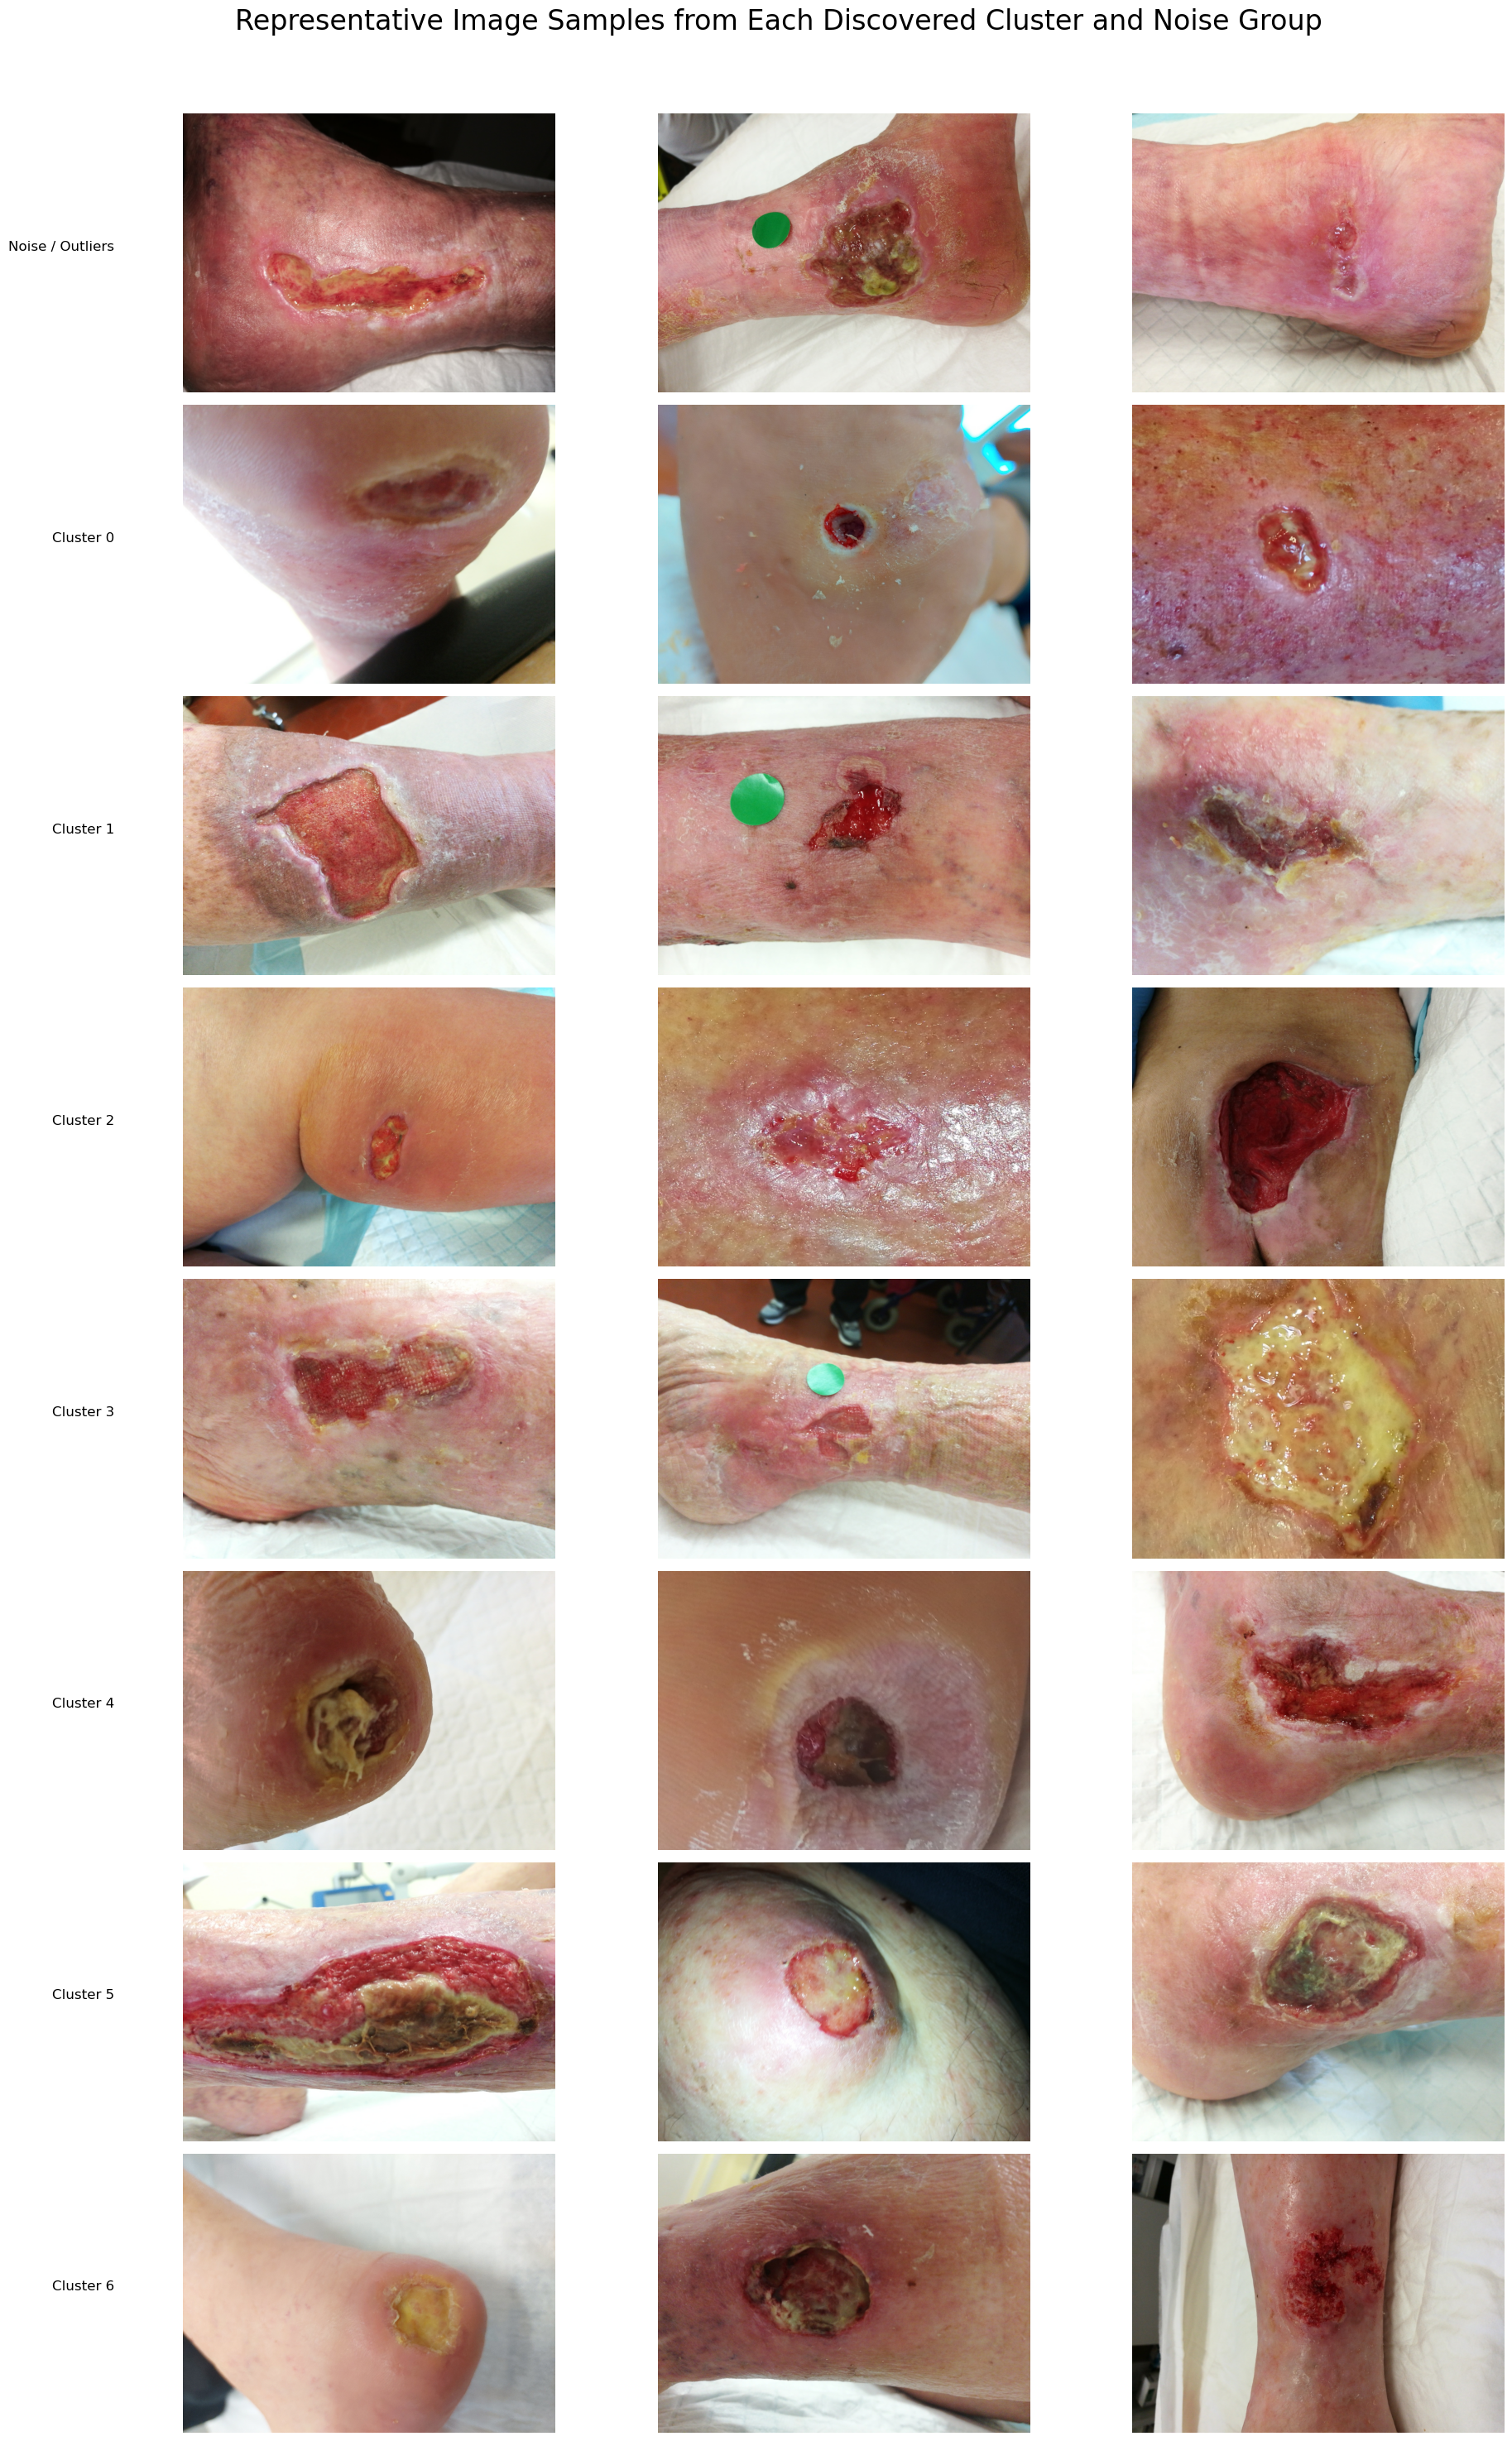

In [1]:
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load Cluster Data and Define Paths
try:
    cluster_map = pd.read_csv("../outputs/image_cluster_map.csv")
    
    # Group image IDs by cluster and sort by cluster label
    cluster_groups = cluster_map.groupby("cluster_label")["image_id"].apply(list)
    cluster_groups = cluster_groups.sort_index()
except FileNotFoundError:
    print("Error: '../outputs/image_cluster_map.csv' not found. Cannot generate samples.")
    cluster_groups = {}

# Define the root directory for your images
DATA_ROOT = "../data"
IMAGE_DIR = os.path.join(DATA_ROOT, "images")

# Set up the Grid Plot 
# We have 7 clusters + 1 noise group, and we'll show up to 5 samples for each.
n_rows = 8  # One row per cluster/group (7 clusters + 1 noise)
n_cols = 3  # Number of samples to show per cluster

# Create a figure with a grid of subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 32)) # Increased height for 8 rows

# Add a main title for the entire figure
fig.suptitle('Representative Image Samples from Each Discovered Cluster and Noise Group', fontsize=24, y=0.92)


# --- Loop Through Clusters and Populate the Grid ---
if not cluster_groups.empty:
    # Get all cluster keys and sort them. This will place -1 (noise) first.
    all_cluster_ids = sorted(cluster_groups.keys())

    for row_idx, cluster_id in enumerate(all_cluster_ids):
        
        # Set the row title using the first subplot's ylabel
        ax_row_title = axes[row_idx, 0]
        
        # Use a conditional label for noise vs. regular clusters
        if cluster_id == -1:
            row_label = "Noise / Outliers"
        else:
            row_label = f"Cluster {cluster_id}"
            
        ax_row_title.set_ylabel(row_label, rotation=0, size='large', labelpad=60, ha='right')

        image_ids = cluster_groups.get(cluster_id, [])
        
        # --- Select samples RANDOMLY ---
        # Determine the number of samples to show (up to n_cols)
        num_to_show = min(len(image_ids), n_cols)
        # Randomly choose samples from the list without replacement
        samples_to_show = np.random.choice(image_ids, size=num_to_show, replace=False)

        for col_idx, image_id in enumerate(samples_to_show):
            ax = axes[row_idx, col_idx]
            
            # Construct the path to the image
            rgb_path = os.path.join(IMAGE_DIR, f"{image_id}.png")

            # Load and display the image
            if os.path.exists(rgb_path):
                img = cv2.imread(rgb_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    ax.imshow(img)
                else:
                    ax.text(0.5, 0.5, 'Load Error', ha='center', va='center')
            else:
                ax.text(0.5, 0.5, 'Not Found', ha='center', va='center')

            # Clean up the axes for a better look
            ax.set_xticks([])
            ax.set_yticks([])
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_visible(False)

        # If a cluster has fewer than num samples, hide the empty subplots
        for col_idx_hide in range(len(samples_to_show), n_cols):
            axes[row_idx, col_idx_hide].axis('off')

# Adjust layout to make sure everything fits nicely
plt.tight_layout(rect=[0, 0, 1, 0.9]) 

# --- Save the Composite Image ---
output_path = "../report/fig/all_cluster_samples.png"
plt.savefig(output_path, dpi=200, bbox_inches='tight')
print(f"Composite sample image saved to {output_path}")

plt.show()


## Analysis of Clusters

### Cluster summary

In [ ]:
# Get all cluster labels that were used
all_clusters = sorted(df_clean["cluster_label"].unique())

# Calculate numeric summary
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
cluster_summary = df_clean.groupby("cluster_label")[numeric_cols].agg(['mean', 'std', 'count'])

# Flatten column names
cluster_summary.columns = ['_'.join(col) for col in cluster_summary.columns]

# Reindex to include missing clusters (like -1 or small ones)
cluster_summary = cluster_summary.reindex(all_clusters).reset_index()

# Fill empty cells if needed
cluster_summary.fillna(np.nan, inplace=True)

# Final preview
print(cluster_summary)

# Save the summary to a CSV file
cluster_summary.to_csv("../outputs/cluster_summary_stats.csv", index=False)
print("Cluster summary saved.")

   cluster_label  bed_slope_mean  bed_slope_std  bed_slope_count  \
0             -1       -0.021291       0.032725               24   
1              0       -0.086327       0.068253               82   
2              1        0.002795       0.038303              143   
3              2        0.019574       0.067961              171   
4              3        0.004956       0.063839              289   
5              4       -0.128872       0.137188              181   
6              5       -0.077957       0.093868               33   
7              6       -0.066758       0.066614              220   

   bed_intercept_mean  bed_intercept_std  bed_intercept_count  bed_r2_mean  \
0            1.201497           3.394545                   24     0.823589   
1           10.882603           7.670029                   82     0.916888   
2            2.227318           7.015311                  143     0.408737   
3           -0.892228           6.511429                  171     0.930461 

### cluster profiles

In [41]:
# Drop the original feature array, as we have the scaled one and the df
feature_columns = df_clean.drop(columns=['image_id', 'cluster_label']).columns

# Calculate the mean of each feature for each cluster
cluster_profiles = df_clean.groupby('cluster_label')[feature_columns].mean()

print("Cluster Profiles (Mean Feature Values):")
display(cluster_profiles)
cluster_profiles.to_csv("../outputs/cluster_profiles.csv", index=True)

Cluster Profiles (Mean Feature Values):


,bed_slope,bed_intercept,bed_r2,bed_fit_success,edge_amplitude,edge_steepness,edge_midpoint,edge_offset,edge_r2,edge_fit_success,...,edge_mean,edge_std,edge_skew,edge_kurtosis,skin_mean,skin_std,skin_skew,skin_kurtosis,spectral_centroid,spectral_entropy
cluster_label,,,,,,,,,,,,,,,,,,,,,
-1,-0.021291,1.201497,0.823589,1.0,-1138.111918,0.027836,691.624018,1.460129,0.964117,1.0,...,0.306722,0.413341,-0.188543,-0.550361,0.036339,0.417636,0.566163,-0.415964,0.007349,1.647678
0,-0.086327,10.882603,0.916888,1.0,-6604.926463,0.027247,-352.225160,6602.341755,0.993608,1.0,...,2.504800,1.219566,0.459649,-0.757399,-0.230539,0.505209,0.609326,-0.470869,0.006075,1.684017
1,0.002795,2.227318,0.408737,1.0,15.912579,0.150472,69.918930,-15.821378,0.957132,1.0,...,1.310803,1.266567,0.044208,-0.772196,-0.104552,0.459407,0.411665,-0.294023,0.005132,1.467821
2,0.019574,-0.892228,0.930461,1.0,131.639619,0.011955,71.613554,-152.761689,0.865651,1.0,...,0.928100,0.775713,-0.364716,-0.891482,-0.010161,0.524111,0.291264,-0.875149,0.006496,1.588855
3,0.004956,-4.497307,0.925856,1.0,124.636530,0.122513,83.054925,-43.485882,0.992012,1.0,...,-2.263546,1.718217,0.078961,-1.236365,0.459306,0.470802,-0.231479,0.076870,0.005401,1.511878
4,-0.128872,22.697732,0.920743,1.0,-318.099975,0.116920,66.878477,318.478164,0.988903,1.0,...,5.092728,3.689791,0.685406,-0.701362,-0.246476,0.730550,0.479816,-0.625433,0.005630,1.643755
5,-0.077957,2.834984,0.946413,1.0,-262.121082,0.242001,116.427815,-165.961611,0.895852,1.0,...,-3.119889,1.897421,0.581388,-0.675676,0.761979,2.628791,-0.329522,-0.388943,0.006052,1.438593
6,-0.066758,6.251126,0.947262,1.0,-76.831066,0.198527,63.083754,76.600628,0.853104,1.0,...,0.663879,0.828199,0.577223,-0.437813,0.010807,0.375724,0.092749,-0.364033,0.009677,2.046339


### Visualize Feature Distributions (box plot)

/var/folders/v4/vp4_jyrx03x_4_00k4fv8vyh0000gn/T/ipykernel_1274/1178140242.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=ax, x='cluster_label', y=feature, data=df_clean, palette="deep")
/var/folders/v4/vp4_jyrx03x_4_00k4fv8vyh0000gn/T/ipykernel_1274/1178140242.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=ax, x='cluster_label', y=feature, data=df_clean, palette="deep")
/var/folders/v4/vp4_jyrx03x_4_00k4fv8vyh0000gn/T/ipykernel_1274/1178140242.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=ax, x='cluster_label', y

Boxplot grid saved to ../report/fig/feature_boxplots_grid.png


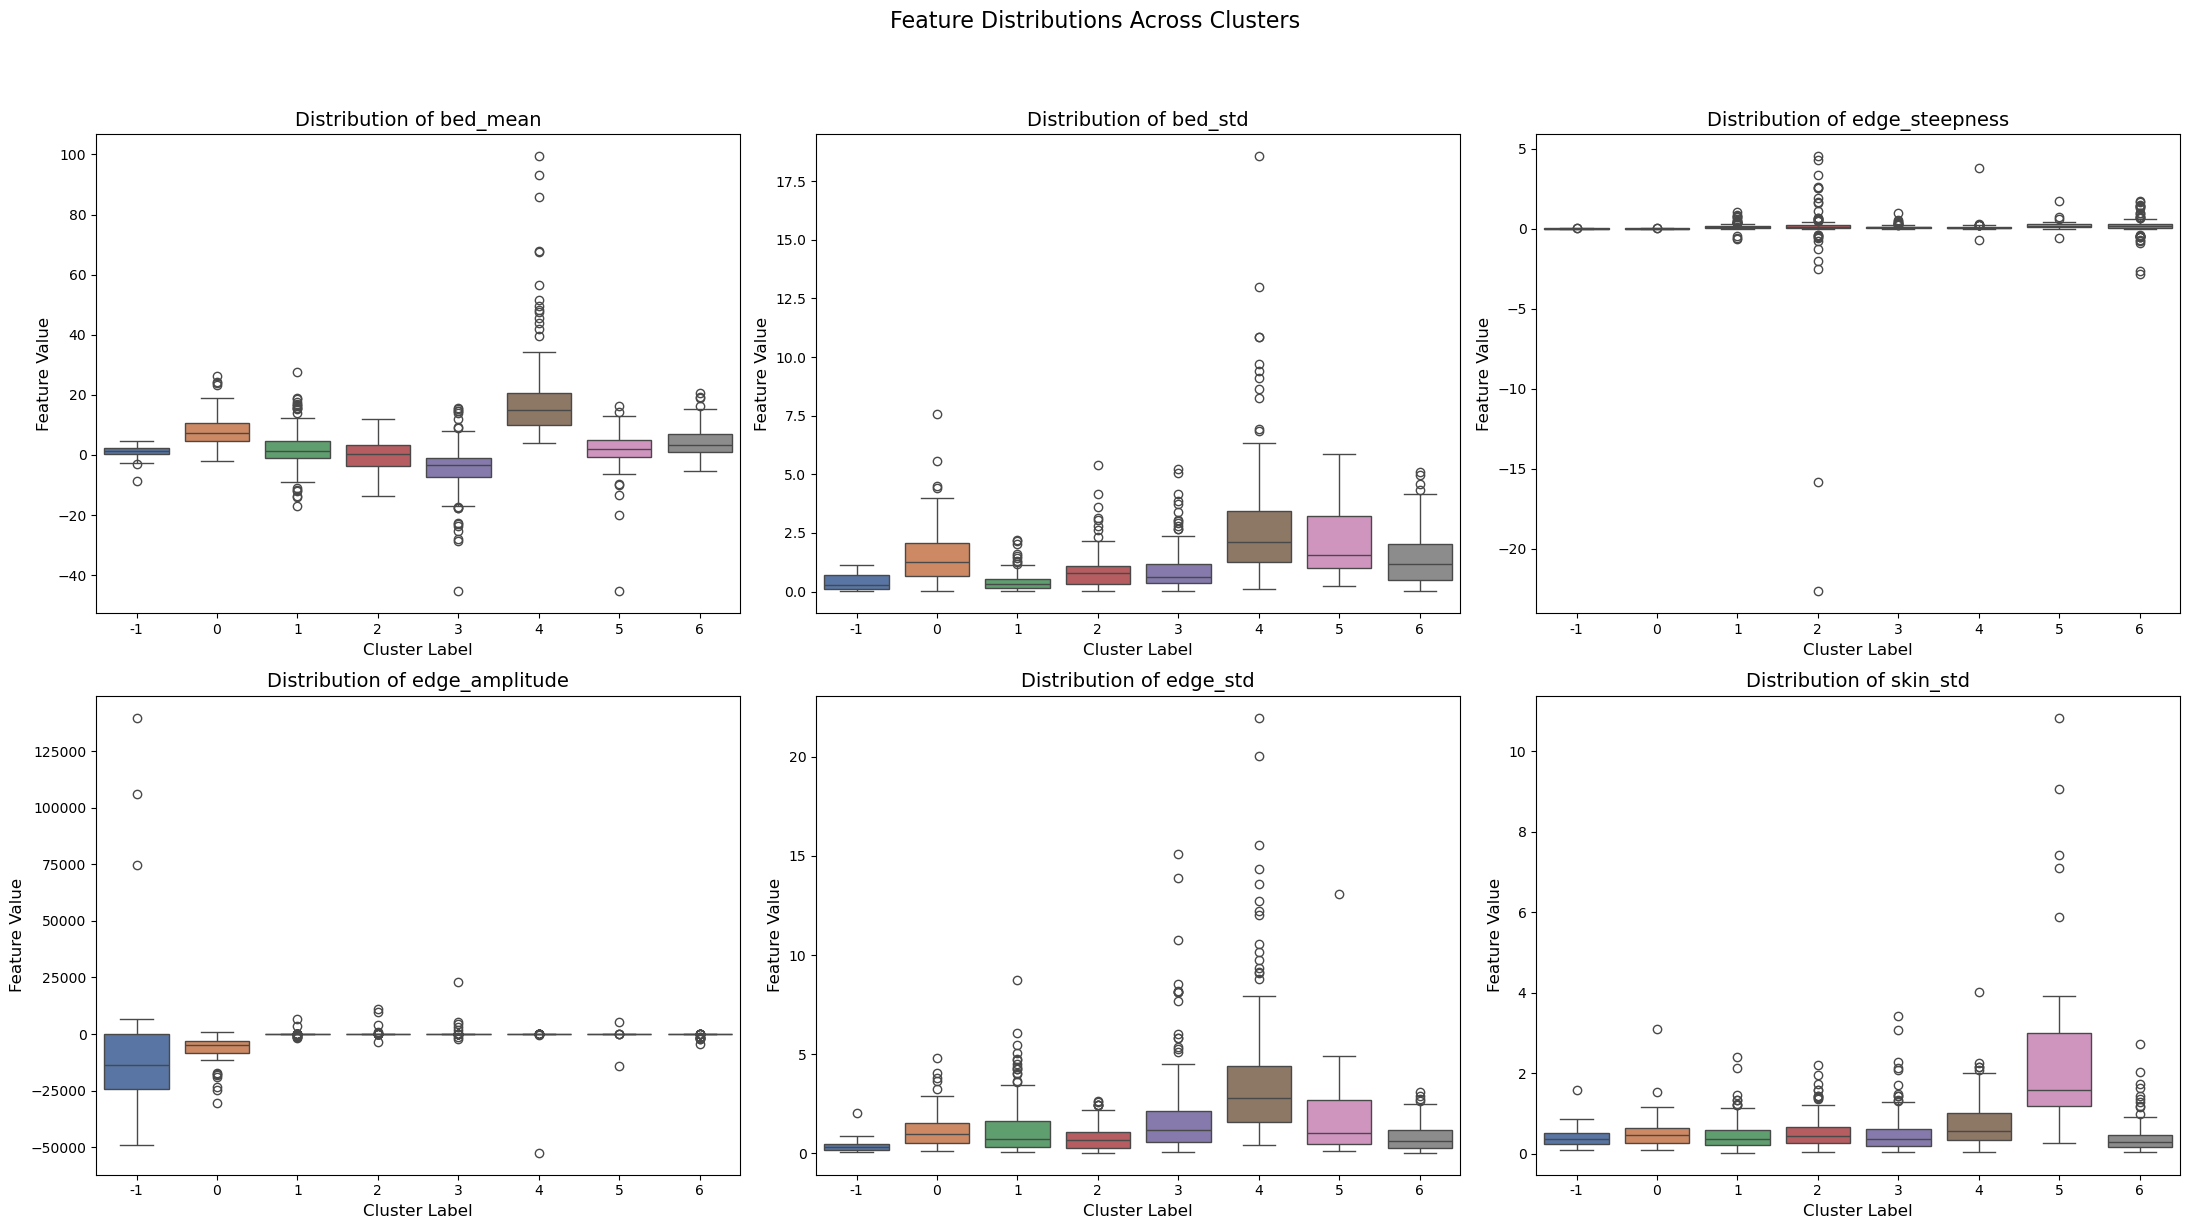

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Some features to investigate their distributions
features_to_plot = [
    'bed_mean', 'bed_std', 
    'edge_steepness', 'edge_amplitude', 'edge_std', 
    'skin_std'
]

# Create a figure to hold the subplots
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()
fig.suptitle('Feature Distributions Across Clusters', fontsize=16, y=1.02)

# Create a box plot for each feature
for i, feature in enumerate(features_to_plot):
    ax = axes[i]
    
    sns.boxplot(ax=ax, x='cluster_label', y=feature, data=df_clean, palette="deep")
    
    ax.set_title(f'Distribution of {feature}', fontsize=14)
    ax.set_xlabel("Cluster Label", fontsize=12)
    ax.set_ylabel("Feature Value", fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
# If there are any unused subplots (e.g., if you plot 5 features on a 3x2 grid),
# this loop will turn them off.
for i in range(len(features_to_plot), len(axes)):
    fig.delaxes(axes[i])

# Adjust the layout to prevent titles and labels from overlapping
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust for suptitle

# Save the figure for your report
output_path = "../report/fig/feature_boxplots_grid.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Boxplot grid saved to {output_path}")

plt.show()